# Confusion Matrices - 2×2

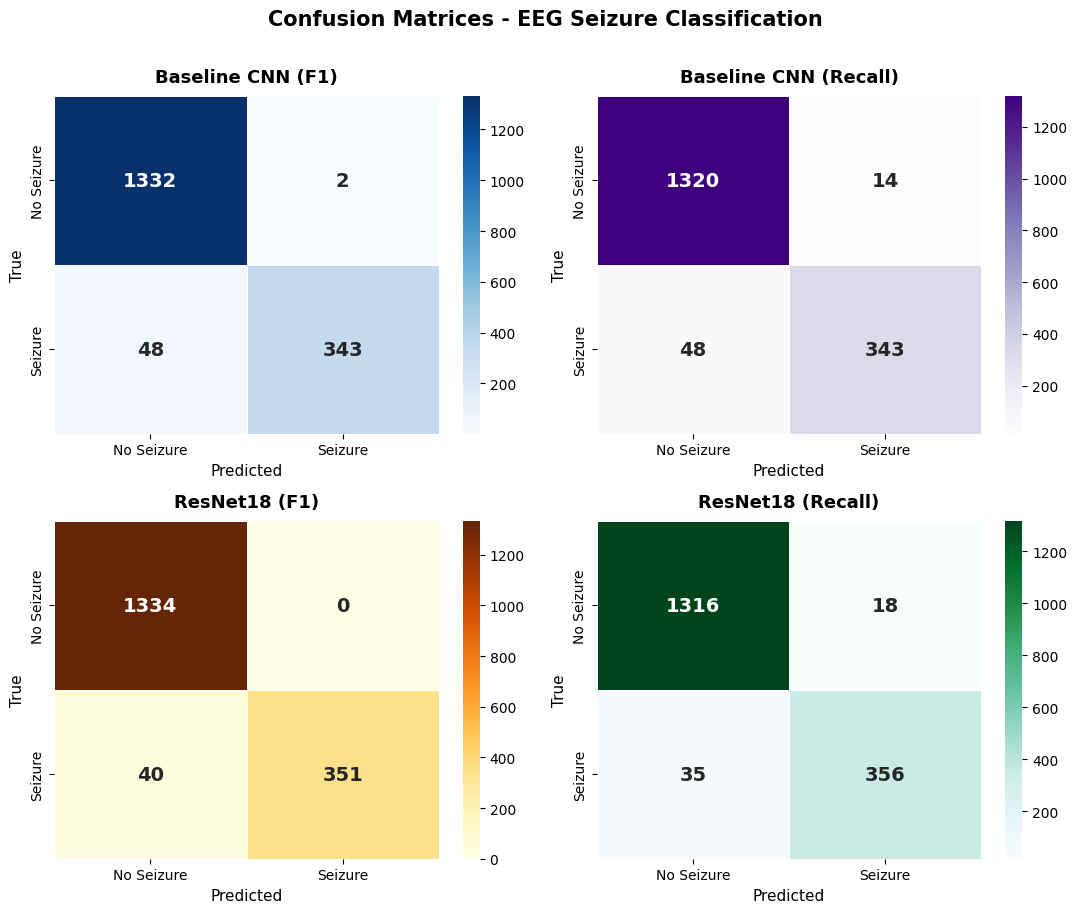

In [4]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_test = np.load('scalograms/X_test.npy')
y_test = np.load('scalograms/y_test.npy')

class ScalogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

test_loader = DataLoader(ScalogramDataset(X_test, y_test), batch_size=64, shuffle=False)

class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            flat = self.features(torch.zeros(1, 1, 178, 178)).view(1, -1).shape[1]
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(flat, 256), nn.ReLU(), nn.Dropout(0.5), nn.Linear(256, 1)
        )
    def forward(self, x): return self.classifier(self.features(x))

class ResNet18Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights=None)
        base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        base.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(512, 1))
        self.model = base
    def forward(self, x): return self.model(x)

def predict(model):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            prob = torch.sigmoid(model(bx.to(device)).squeeze(-1)).cpu().numpy()
            preds.extend((prob > 0.5).astype(int).tolist())
            trues.extend(by.numpy().astype(int).tolist())
    return confusion_matrix(trues, preds)

configs = [
    ('Baseline CNN (F1)',     BaselineCNN,        'best_baseline_cnn.pt',        'Blues'),
    ('Baseline CNN (Recall)', BaselineCNN,        'best_baseline_cnn_recall.pt', 'Purples'),
    ('ResNet18 (F1)',         ResNet18Classifier, 'best_resnet18.pt',            'YlOrBr'),
    ('ResNet18 (Recall)',     ResNet18Classifier, 'best_resnet18_recall.pt',     'BuGn'),
]

cms = []
for title, ModelClass, ckpt, _ in configs:
    m = ModelClass().to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
    cms.append(predict(m))

labels = ['No Seizure', 'Seizure']
fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for ax, (title, _, _, cmap), cm in zip(axes.flatten(), configs, cms):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.5, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('True', fontsize=11)

fig.suptitle('Confusion Matrices - EEG Seizure Classification',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/confusion_matrices_2x2.png', dpi=300, bbox_inches='tight')
plt.show()
